In [1]:
import switchy.CloneStats as cs
import pandas as pd
import numpy as np
import sys
import os
import time
import random
import copy
import math
import scanpy as sc
%matplotlib inline
from matplotlib import pyplot as plt
import matplotlib as mpl
import seaborn as sns
import autoreload
import scipy
params = {
    'font.size': 12,
    'axes.titlesize': 12,
    'axes.labelsize': 12,
    'legend.fontsize': 12,
    'xtick.labelsize': 8,
    'ytick.labelsize': 10,
    'font.family': "Helvetica",
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'figure.dpi': 100
   }

mpl.rcParams.update(params)

sns.set_style("ticks")

savefig_args = {"dpi": 300, "bbox_inches": "tight", "pad_inches": 0, "transparent": True}
mpl.rc('savefig', dpi=300)
output_dir = "figures/ClonalGenesCorrelations"
output_suffix = ""
output_formats = [".png", ".pdf"]

def save_figure(fig, name, output_dir=output_dir, output_suffix=output_suffix, output_formats=output_formats, savefig_args=savefig_args):
    for output_format in output_formats:
        fig.savefig(output_dir + "/" + name + output_suffix + output_format, **savefig_args)
    return None

pd.set_option('display.max_rows', 50)
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 100)
%load_ext autoreload
%autoreload 2
cfgFile = '../switchy/Prototyping.ini'

In [2]:
parameters, io, config = cs.readConfig(cfgFile)
    
adata, df = cs.prepareData(io['CountsFile'],
                                parameters['datatype'], 
                                parameters.getboolean('highly_variable'),
                                int(parameters['n_highly_variable']),
                                parameters.getboolean('onlyClones'), 
                                parameters.getboolean('remove_immune_receptors'), 
                                parameters.getboolean('normalize'),
                                parameters.getboolean('filterCells'))

(3394, 98) (17819, 2) shape of adata after filtering 


def compareSD(df, LabelsTesting, num_shuffles, label, gene):
    "For each gene compare the mean variances of a shuffled labeling to the observed labeling"
    LabelsTesting.loc[:,'gene_name'] = df[gene]
    mean_shuffled_variances = []
    observedlabel_var = LabelsTesting.groupby(label)['gene_name'].std()
    mean_observedlabel_variance = observedlabel_var.mean()
    # do the shuffling
    for i in range(num_shuffles):
        # create copy
        LabelsTestingCopy = LabelsTesting.copy(deep = True)
        #shuffle labels
        LabelsTestingCopy.loc[:, label] = np.random.permutation(LabelsTesting[label].values)
        # groupby by label and compute variance
        shuffled_variances = LabelsTestingCopy.groupby(label)['gene_name'].std()
        # Mean variance of every labeled group
        mean_shuffled_variances.append(shuffled_variances.mean())
    #make list into series TODO refactor to just add to a series?
    #This is the distribution of shuffled variances
    mean_shuffled_variances = pd.Series(mean_shuffled_variances)
    # Number of times shuffled variances are less than observed label variance, higher number would be intragroup variance is higher
    test = mean_shuffled_variances <= mean_observedlabel_variance
        # less equal to observed (i.e. True's) by the number of tests
        # stat of 1 would be that shuffled variances always less or equal, 0 would be shuffled variances always more 
        # this is a frequentist p value? kinda ... we'll call it a score
    gene_score = test.sum() / test.shape[0]
    return gene_score, gene, mean_shuffled_variances, mean_observedlabel_variance

selector = adata.obs[adata.obs['Exp_Labels'].str.contains('Activation')].index

df = df[df.index.isin(selector)]

adata_obs = adata.obs[adata.obs.index.isin(df.index)]

In [429]:
adata_obs = adata.obs

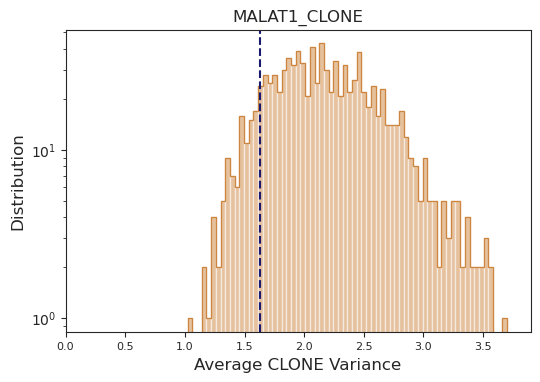

In [433]:
fig = cs.plotTestHist(df, adata_obs, 1000, 'MALAT1', 'CLONE')

AttributeError: 'Figure' object has no attribute 'xlabel'

In [434]:
save_figure(fig, 'MALAT1_TestHist', output_dir='../figures/ClonalGenesCorrelations/7.14_LabMeeting/')

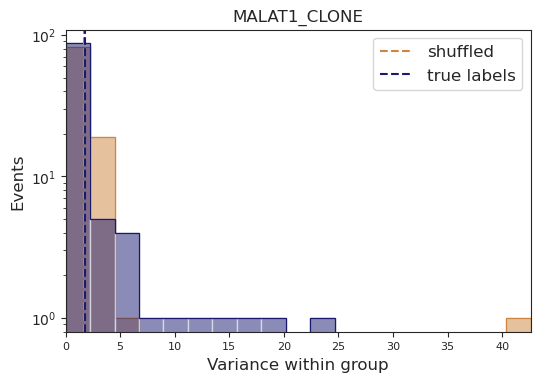

In [372]:
fig, data, data_shuffled = cs.plotEgHists(df, adata_obs, 1, 'MALAT1', 'CLONE')

In [373]:
save_figure(fig, 'MALAT1_ShuffleEg', output_dir='../figures/ClonalGenesCorrelations/7.14_LabMeeting/')

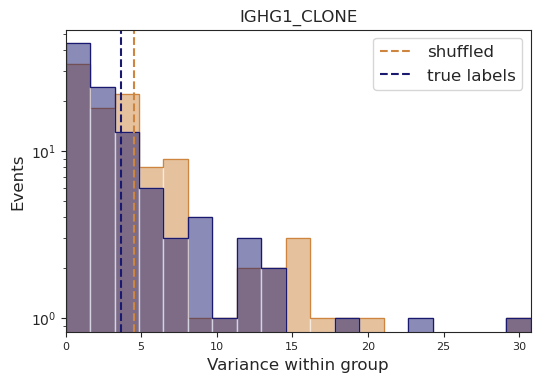

In [279]:
data, data_shuffled = cs.plotEgHists(df, adata_obs, 1, 'IGHG1', 'CLONE')

Text(0.5, 1.0, 'IGKC_Clone')

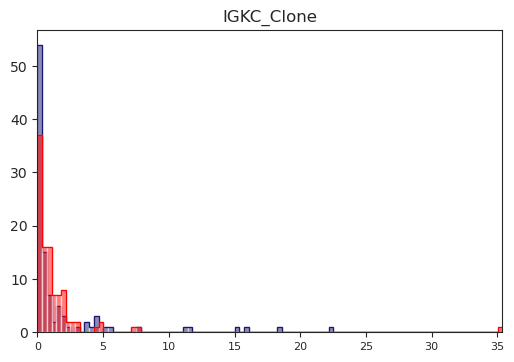

In [231]:
gene = 'IGKC'
label = 'Clone'
data = data[data > 0]

data_shuffled = data_shuffled[data_shuffled > 0]
fig, ax = plt.subplots(1,1)
xmax = data_shuffled.max() + 0.2
bins = np.linspace(0, xmax, 100)
plt.hist(data, bins = bins, color = 'midnightblue', alpha = 0.5)
plt.hist(data, bins = bins, color = 'midnightblue', histtype='step')
plt.hist(data_shuffled, bins = bins, color = 'red', alpha = 0.5)
plt.hist(data_shuffled, bins = bins, color = 'red', histtype='step')

#plt.axvline(mean_observedlabel_variance, 0, 1, c = 'red', ls = '--')
plt.yscale('linear')
plt.xscale('linear')
plt.xlim(0, xmax)
plt.title(gene + '_' + label)

In [404]:
adata_obs = adata.obs[adata.obs.index.isin(df.index)]

In [401]:
adata[adata]

AnnData object with n_obs × n_vars = 3394 × 27108
    obs: 'Donor_x', 'Exp_Labels', 'Condition_Labels', 'SEQUENCE_ID', 'SEQUENCE_INPUT', 'FUNCTIONAL', 'IN_FRAME', 'STOP', 'MUTATED_INVARIANT', 'INDELS', 'LOCUS', 'V_CALL', 'D_CALL', 'J_CALL', 'SEQUENCE_VDJ', 'SEQUENCE_IMGT', 'V_SEQ_START', 'V_SEQ_LENGTH', 'V_GERM_START_VDJ', 'V_GERM_LENGTH_VDJ', 'V_GERM_START_IMGT', 'V_GERM_LENGTH_IMGT', 'NP1_LENGTH', 'D_SEQ_START', 'D_SEQ_LENGTH', 'D_GERM_START', 'D_GERM_LENGTH', 'NP2_LENGTH', 'J_SEQ_START', 'J_SEQ_LENGTH', 'J_GERM_START', 'J_GERM_LENGTH', 'JUNCTION', 'JUNCTION_LENGTH', 'GERMLINE_IMGT', 'V_SCORE', 'V_IDENTITY', 'V_EVALUE', 'V_CIGAR', 'D_SCORE', 'D_IDENTITY', 'D_EVALUE', 'D_CIGAR', 'J_SCORE', 'J_IDENTITY', 'J_EVALUE', 'J_CIGAR', 'FWR1_IMGT', 'FWR2_IMGT', 'FWR3_IMGT', 'FWR4_IMGT', 'CDR1_IMGT', 'CDR2_IMGT', 'CDR3_IMGT', 'CLONE', 'GERMLINE_IMGT_D_MASK', 'GERMLINE_V_CALL', 'GERMLINE_D_CALL', 'GERMLINE_J_CALL', 'MU_COUNT_SEQ_R', 'MU_COUNT_SEQ_S', 'MU_FREQ_SEQ_R', 'MU_FREQ_SEQ_S', 'ISOTYPE_by_

In [407]:
adata_obs.Exp_Labels.value_counts()

Activation_2            608
Activation_0            292
Activation_4            276
Activation_1            215
Activation_3            205
PlasmaCells_2             0
PlasmaCells_1             0
Naive_3                   0
Naive_2                   0
Naive_1                   0
Allergic_Individuals      0
Name: Exp_Labels, dtype: int64

In [441]:
sns.set(rc={'figure.figsize':(15, 5)})

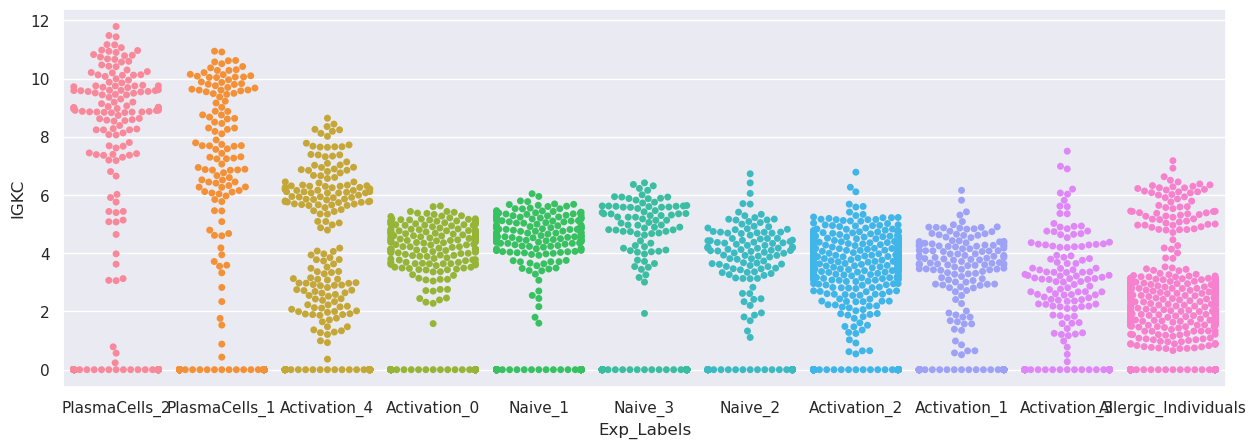

In [442]:
g = cs.plotSwarm(df, adata_obs, 'IGKC', 'Exp_Labels')
g = cs.plotSwarm(df, adata_obs, 'IGKC', 'Exp_Labels')

In [ ]:
g = cs.pl(df, adata_obs, 'IGKC', 'Exp_Labels')

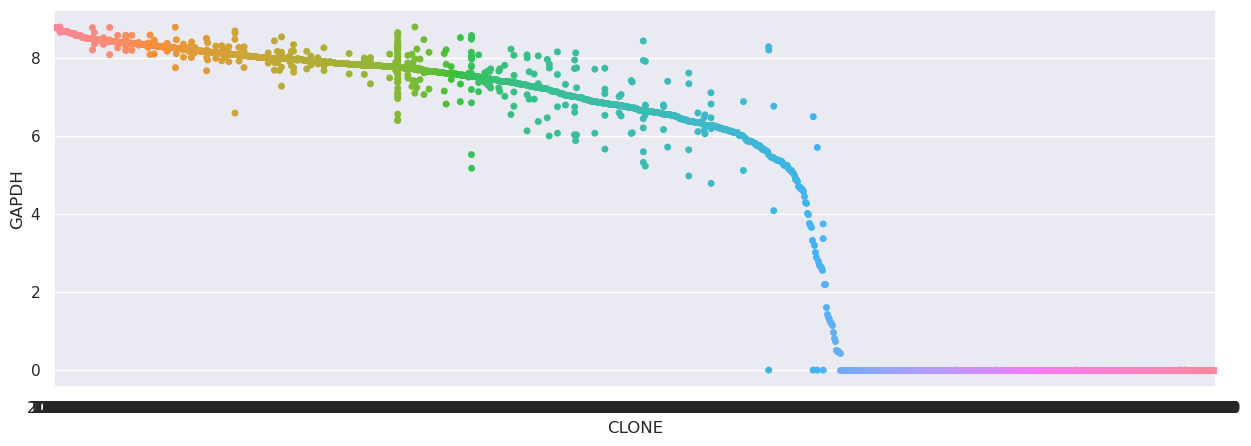

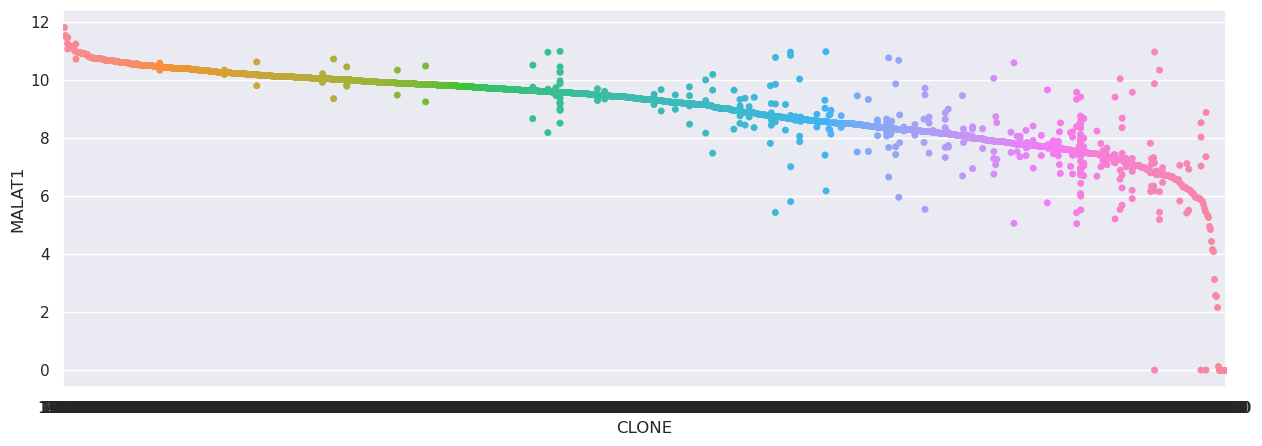

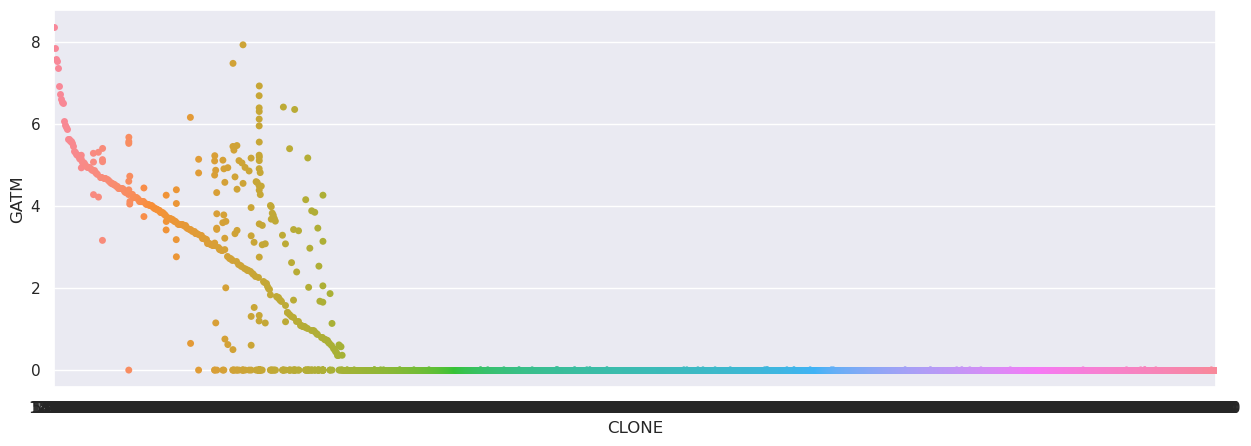

In [443]:
cs.plotWaterfall(df, adata.obs, 'GAPDH', 'CLONE')
cs.plotWaterfall(df, adata.obs, 'MALAT1', 'CLONE')
cs.plotWaterfall(df, adata.obs, 'GATM', 'CLONE')


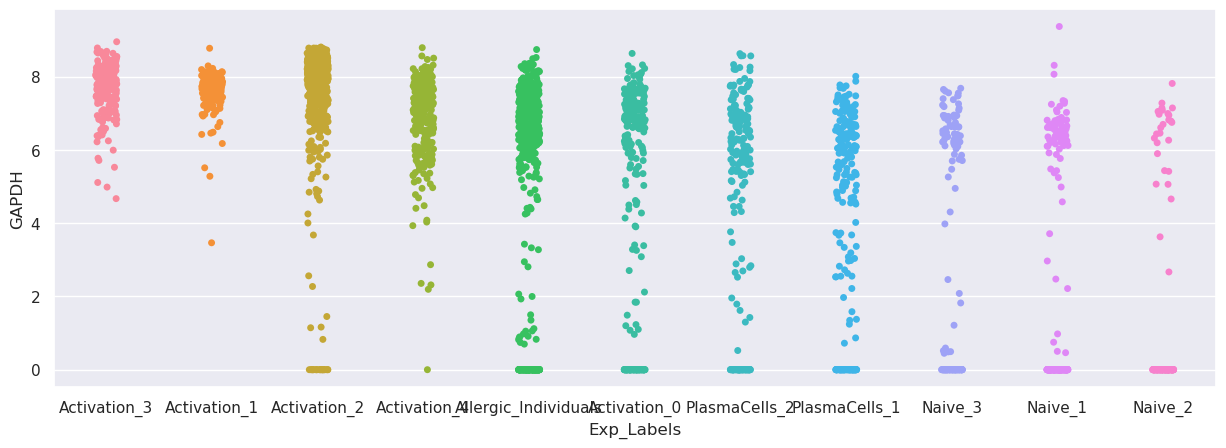

In [446]:
cs.plotWaterfall(df, adata.obs, 'GAPDH', 'Exp_Labels')


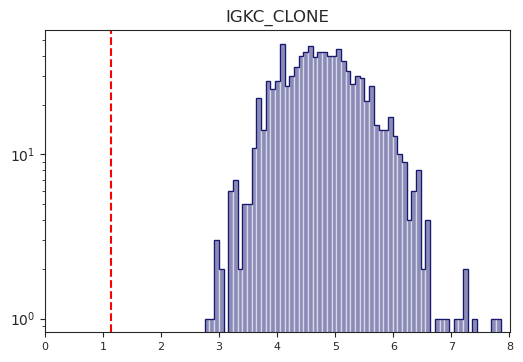

In [236]:
fig = cs.plotTestHist(df, adata.obs, 1000, 'IGKC', 'CLONE')

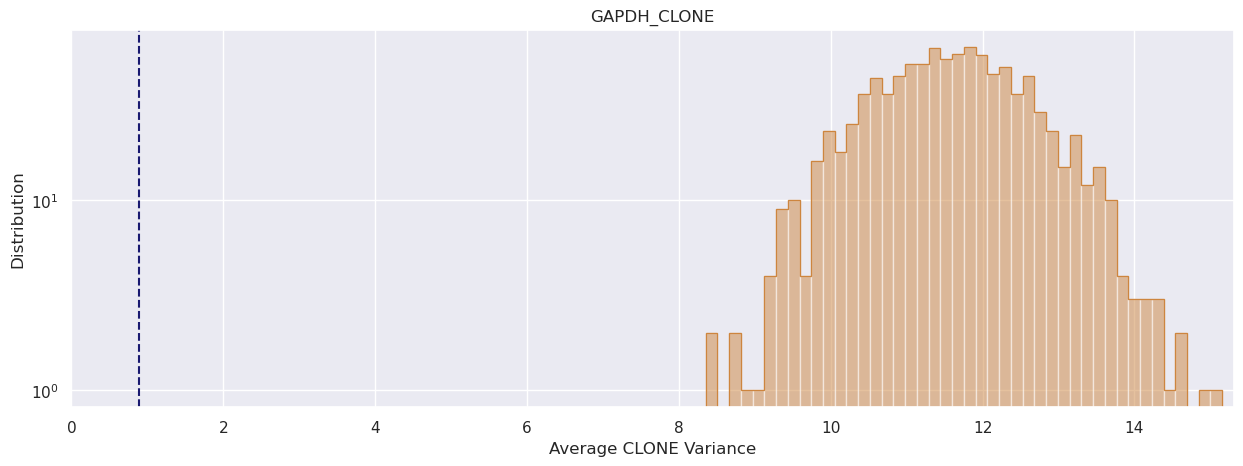

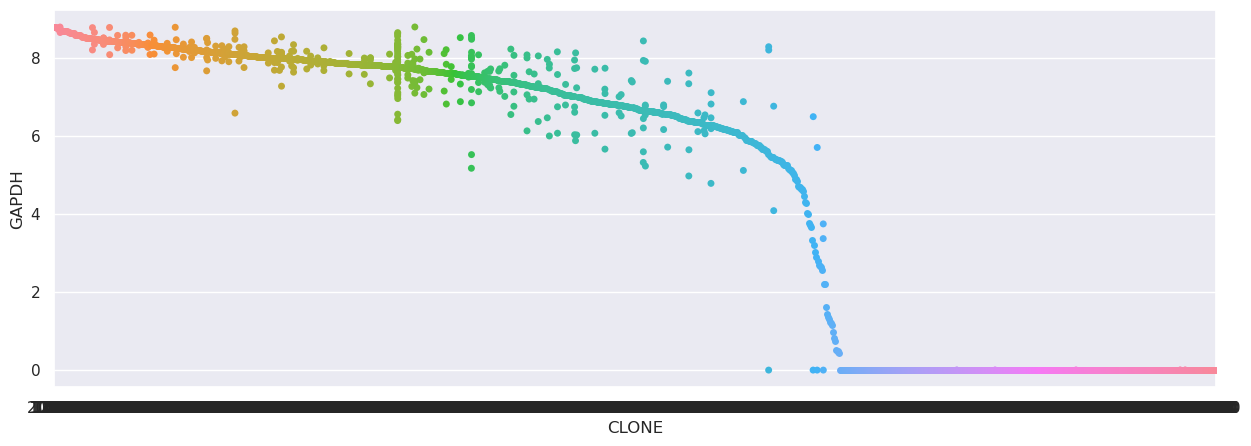

In [444]:
cs.plotTestHist(df, adata.obs, 1000, 'GAPDH', 'CLONE')
cs.plotWaterfall(df, adata.obs, 'GAPDH', 'CLONE')

In [113]:
def plotCI(df, adata_obs, num_shuffles, gene, label, alpha):
    # This is expensive to do twice, like this because I really am only plotting a subset of hits 
    LabelsTesting = pd.merge(adata.obs[label], df[gene], left_index=True, right_index=True)
    tested_gene = []
    statistics = []
    # get the ordered means of the true labeling
    observedlabel_mean = LabelsTesting.groupby(label)[gene].mean().sort_values(ascending = False)
    ci_df = pd.DataFrame(observedlabel_mean)
    # set up shuffling loop
    #mean_shuffled_variances
    #initialize dataframe
    #mean_observedlabel_variance = .mean()
    for i in range(num_shuffles):
        # create copy out of superstition
        LabelsTestingCopy = LabelsTesting.copy(deep = True)
        # shuffle labels
        LabelsTestingCopy[label] = np.random.permutation(LabelsTestingCopy[label].values)
        # 
        shuffled_means = LabelsTestingCopy.groupby(label)[gene].mean()
        ci_df = pd.merge(ci_df, shuffled_means, left_index=True, right_index=True)
    #ci_df.iloc[:,1:].mean()
    true_ordered_means = ci_df.iloc[:,0]

    shuffled_means = ci_df.iloc[:,1:]
    # Using T distribution
    shuffled_means['lower'] = shuffled_means.apply(lambda row: scipy.stats.t.interval(alpha, row.shape[0]-1, loc = row.median(), scale=row.sem())[0], axis = 1)
    shuffled_means['upper'] = shuffled_means.apply(lambda row: scipy.stats.t.interval(alpha, row.shape[0]-1, loc = row.median(), scale=row.sem())[1], axis = 1)
    shuffled_means['lower_quant'] = shuffled_means.quantile(q = 0.025, axis = 1)
    shuffled_means['upper_quant'] = shuffled_means.quantile(q = 0.975, axis = 1)
    
    # merge data for plotting 
    data = pd.merge(true_ordered_means, shuffled_means, left_index = True, right_index= True)
    data.reset_index(inplace = True)
    data[label] = data[label].astype('str')
    fig, ax = plt.subplots()
    
    x = data[label]
    # Frequentist confidence intervals
    f_lowci = data['lower_quant']
    f_upci = data['upper_quant']
    true_data = true_ordered_means
    g_lowci = data['lower']
    g_upci = data['upper']
    ax.plot(x, true_data, label = 'True Data Order')
    #ax.plot(x, upci)
    #ax.plot(x, lowci)
    ax.fill_between(x, f_lowci, f_upci, alpha = 0.2, color = 'k', label = 'CI using real quantiles')
    ax.fill_between(x, g_lowci, g_upci, alpha = 0.2, color = 'r', label = 'CI using T distribution')
    plt.xlabel(label)
    plt.ylabel(gene + ' \n mean expression (scaled)')
    plt.xticks()
    ax.legend()
    return data, shuffled_means

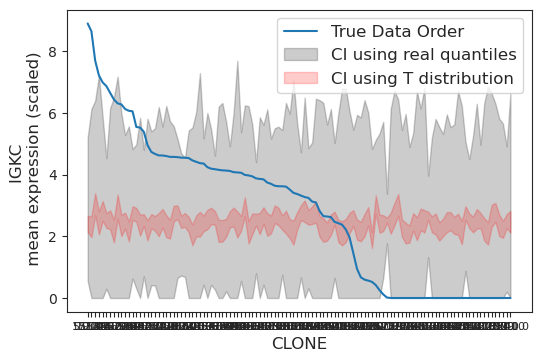

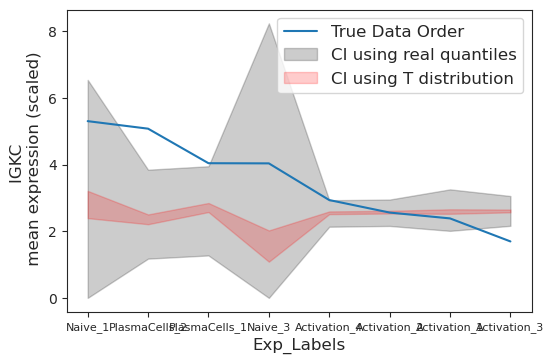

In [114]:
data = plotCI(df, adata.obs, 100, 'IGKC', 'CLONE', 0.95)
data = plotCI(df, adata.obs, 100, 'IGKC', 'Exp_Labels', 0.95)

In [ ]:
data = plotCI(df, adata.obs, 100, 'JCHAIN', 'CLONE', 0.95)
data = plotCI(df, adata.obs, 100, 'JCHAIN', 'Exp_Labels', 0.95)

In [30]:
gene_names = ['IGHG1', 'IGHG2', "IGHG4", 'IGHG3', 'IGHM', 'IGHD', 'IGHA1', 'IGHE', "IGHA2"]



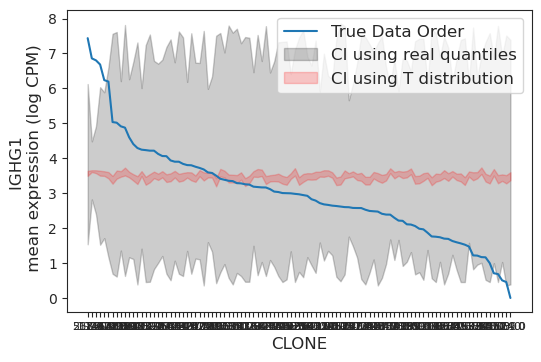

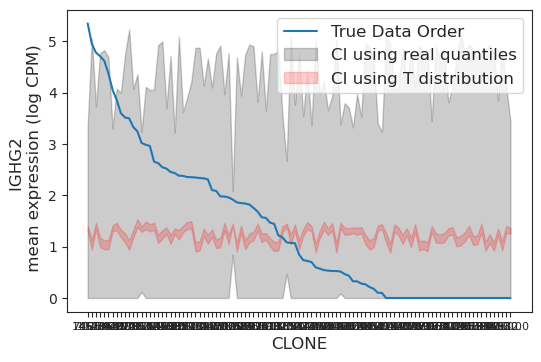

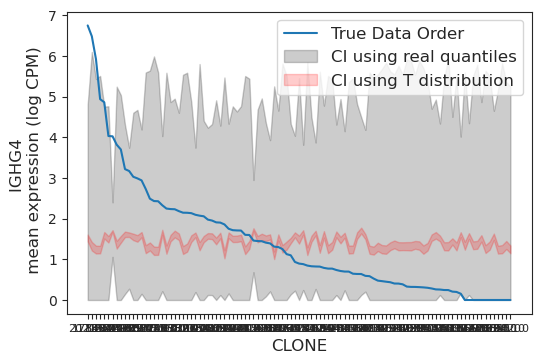

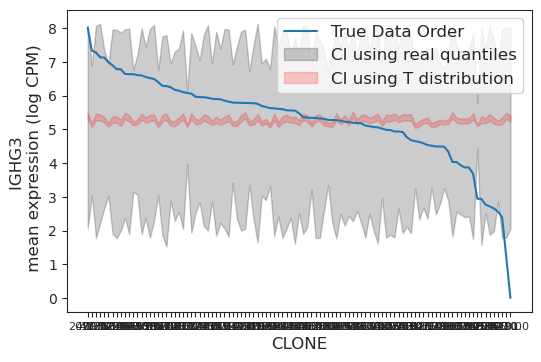

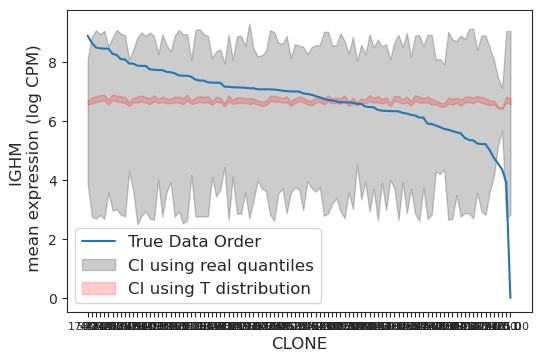

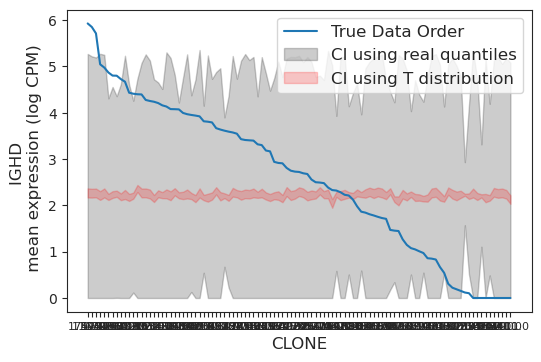

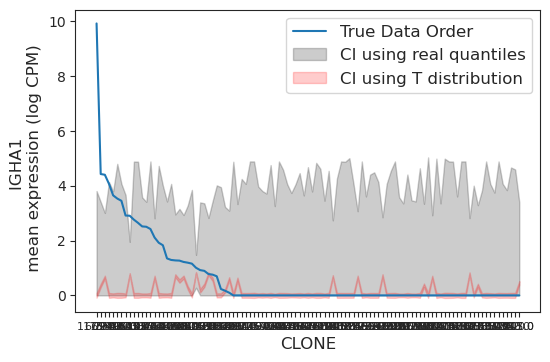

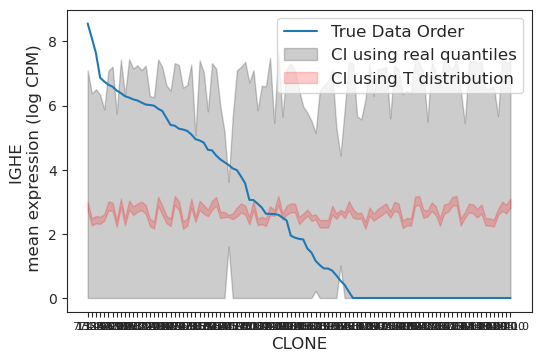

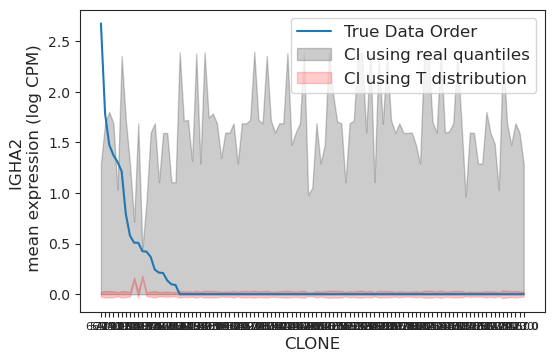

In [31]:
for gene in gene_names:
    data = plotCI(df, adata.obs, 1000, gene, 'CLONE', 0.95)

In [ ]:
for gene in gene_names:
    data = plotCI(df, adata.obs, 100, gene, 'CLONE', 0.95)
    data = plotCI(df, adata.obs, 100, gene, 'Exp_Labels', 0.95)

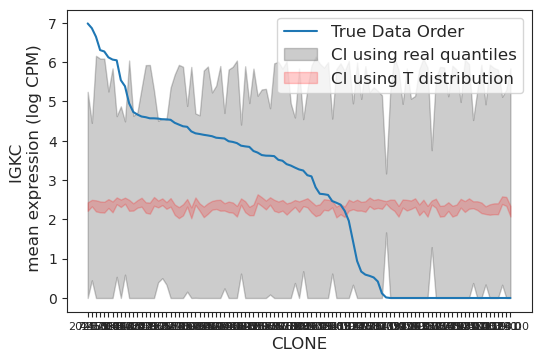

In [96]:
data, shuffledmeans = plotCI(df, adata.obs, 1000, 'IGKC', 'CLONE', 0.99)

In [ ]:
data, shuffledmeans = plotCI(df, adata.obs, 1000, 'IGKC', 'CLONE', 0.99)

for i in range(5):
    oneClone = shuffledmeans.iloc[i,:][:-5].values
    measurements = oneClone
    stats.probplot(measurements, dist = "norm", plot=pylab)

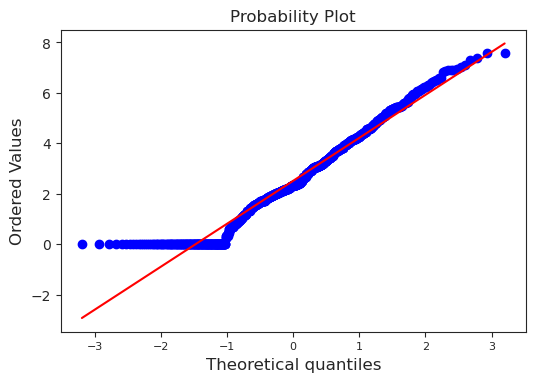

In [102]:
# 
import statsmodels
# generate t distribution
import scipy.stats as stats
import pylab
import numpy as np

oneClone = shuffledmeans.iloc[2,:][:-5].values

measurements = oneClone
#measurements = np.random.normal(loc = oneClone.mean(), scale = oneClone.std(), size = 1000)
g = stats.probplot(measurements, dist = "norm", plot=pylab)

## Division Data

In [5]:
parameters, io, config = cs.readConfig(cfgFile)
    
adata, df = cs.prepareData(io['CountsFile'],
                                parameters['datatype'], 
                                parameters.getboolean('highly_variable'),
                                int(parameters['n_highly_variable']),
                                parameters.getboolean('onlyClones'), 
                                parameters.getboolean('remove_immune_receptors'), 
                                parameters.getboolean('normalize'),
                                parameters.getboolean('filterCells'))

(3394, 98) (17819, 2) shape of adata after filtering 


# Cells which still have no division information even though it seems like they should
# not too worried about this because 4 of the 5 don't have bracer assemblies, suggesting I wouldn't even use them.  
adata.obs[(adata.obs.DivisionNumber == 'None') & (adata.obs.Condition_Labels == 'Activation')]

In [11]:
adata.obs['DivisionNumber'] = adata.obs.DivisionNumber.str.replace('None', 'No Tracking')


adata.obs.loc[:,'DivisionNumber'] = adata.obs.DivisionNumber.str.replace('No Tracking', '100')
adata.obs.loc[:,'DivisionNumber'] = adata.obs.DivisionNumber.str.replace('Max', '7')


adata.obs['DivisionNumber'] = pd.to_numeric(adata.obs['DivisionNumber'])

In [7]:
selector = adata.obs.CLONE.value_counts() > 1
selector = selector[selector == True]

# Only Cells with clones?
_adata = adata[adata.obs.CLONE.isin(selector.index), :]
_df = df[df.index.isin(_adata.obs.index)]

In [461]:
tests_novariable = tests[~tests['gene'].str.contains('IGKV|IGLV|IGHV')]

# Get a bundle of Genes to test 
genes = tests_novariable.sort_values('score')[:30].gene.values


In [20]:
# Create a new dataframe with the comparison as a column, the added division number, and pearson correllation
import itertools
def compareGenesbyDivision(df, adata, genes):
    comparison = []
    clonal = []
    division_number = []
    pearsons = []
    df = df[genes]
    for cell1, cell2 in itertools.combinations(df.index, 2):
        # Clone Test Comparison
        if adata.obs.loc[cell1].CLONE == adata.obs.loc[cell2].CLONE:
            clonal.append(1)
        else:
            clonal.append(0)
        # Add Comparison Name    
        comparison.append(cell1 + '*' + cell2)
        # Add Division Numbers
        division_number.append(adata.obs.loc[cell1].DivisionNumber+ adata.obs.loc[cell2].DivisionNumber)
        cellpearson = np.corrcoef(df.loc[cell1], df.loc[cell2])[0][1]
        pearsons.append(cellpearson)

    # Construct the df
    divisiondf = pd.DataFrame([comparison, clonal, division_number, pearsons], )
    divisiondf = divisiondf.T
    divisiondf.columns = ['Comparison', 'Clonal?', 'DivisionSum', 'Pearson']
    
    return divisiondf

In [14]:
# Load the Tests
CLONE_tests = pd.read_csv('../outputs/CLONE_tests.csv', index_col = 0)
ENV_tests = pd.read_csv('../outputs/Exp_Labels_tests.csv', index_col = 0)

In [15]:
ENV_genes = ENV_tests[ENV_tests['corrected_pvalue'] < 0.35]

In [16]:
ENV_genes = ENV_genes.gene

In [17]:
CLONE_genes = CLONE_tests[CLONE_tests['corrected_pvalue'] < 0.01]

In [18]:
CLONE_genes = CLONE_genes.gene.to_list()[:9]

In [ ]:
divisiondf_CLONE = compareGenesbyDivision(_df, _adata, CLONE_genes)

In [29]:
divisiondf_CLONE['Clonal?'].value_counts()

0    64999
1     1067
Name: Clonal?, dtype: int64

In [47]:
divisiondf_CLONE.Comparison.str.split('*', expand = True)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,CTY,L1,CTY,J10,None,None,None,None,None,None,None,None,None,None
1,CTY,L1,CTY,P23,None,None,None,None,None,None,None,None,None,None
2,CTY,L1,MS,IL4,O3,None,None,None,None,None,None,None,None,None
3,CTY,L1,CTY,B15,None,None,None,None,None,None,None,None,None,None
4,CTY,L1,MS,IL4,N11,None,None,None,None,None,None,None,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
66061,B107914,J6,B107914,K13,None,None,None,None,None,None,None,None,None,None
66062,B107914,J6,B107914,O4,None,None,None,None,None,None,None,None,None,None
66063,B107906,I20,B107914,K13,None,None,None,None,None,None,None,None,None,None
66064,B107906,I20,B107914,O4,None,None,None,None,None,None,None,None,None,None


In [118]:
# Getting the Genes which may be significant: 

tests_novariable.sort_values('score')[200:230]
genes = tests_novariable.sort_values('score')[200:230].gene.values


In [396]:
CLONE_tests[CLONE_tests['corrected_pvalue'] < 0.01].highly_variable.value_counts()

False    650
True     132
Name: highly_variable, dtype: int64

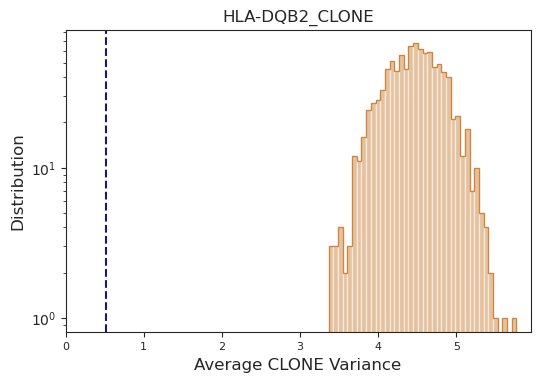

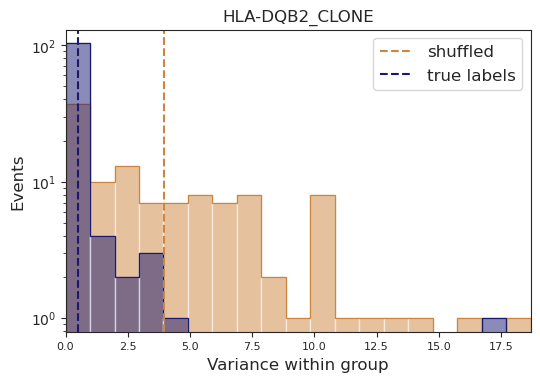

In [435]:
gene = 'HLA-DQB2'
fig1 = cs.plotTestHist(df, adata_obs, 1000, gene, 'CLONE')
fig2 = cs.plotEgHists(df, adata_obs, 1, gene, 'CLONE')

In [ ]:
save_figure(fig1, 'HLA-DQB2_CLONEtest', )

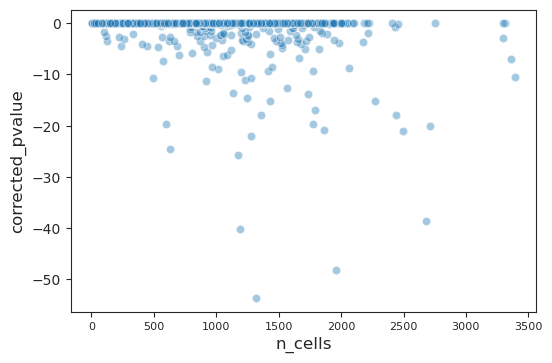

In [143]:
sns.scatterplot(x = tests['n_cells'], y = np.log(tests['corrected_pvalue']), alpha=0.4)


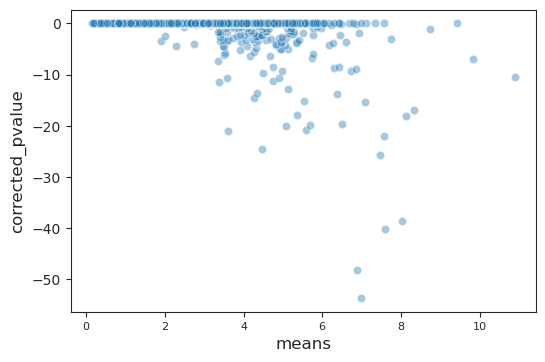

In [144]:
sns.scatterplot(x = tests['means'], y = np.log(tests['corrected_pvalue']), alpha = 0.4)

In [164]:
propsig = tests[tests.corrected_pvalue < 0.01].shape[0] / tests.shape[0]

propsig = tests[tests.corrected_pvalue < 0.01].shape[0] / 4000

In [381]:
gene = 'SELL'
data = cs.plotCI(df, adata, 1000, gene, 'CLONE', 0.95)

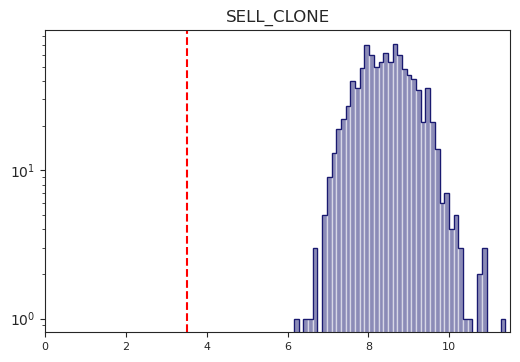

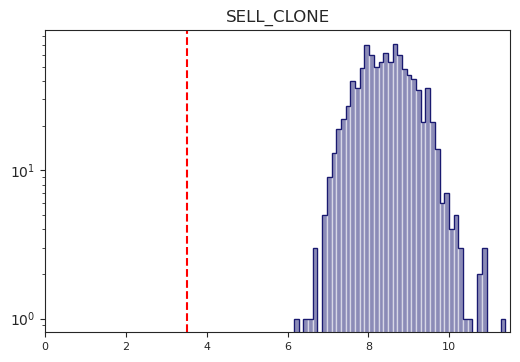

In [383]:
gene = 'SELL'
cs.plotTestHist(df, adata_obs, 1000, gene, 'CLONE')

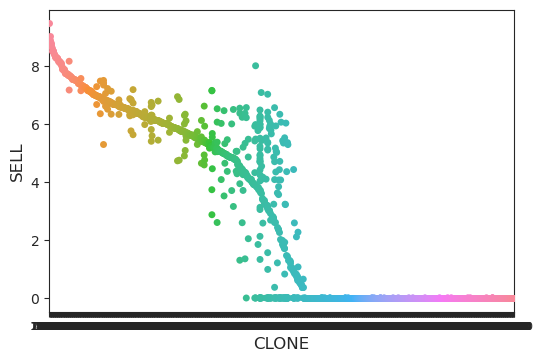

In [436]:
cs.plotWaterfall(df, adata_obs, 'SELL', 'CLONE')

In [389]:
list(tests[tests.corrected_pvalue < 0.01].gene)

['IGLC3',
 'IGKC',
 'CCL17',
 'MS4A1',
 'CCL22',
 'PRDM1',
 'JCHAIN',
 'ACTBP2',
 'AFF3',
 'ENSG00000277048',
 'IGHE',
 'SELL',
 'IGHM',
 'LGALS1',
 'IGHG1',
 'LCP1',
 'MCM7',
 'COMT',
 'CD83',
 'MALT1',
 'ANXA6',
 'FSCN1',
 'ACTN4',
 'INSIG1',
 'CEP128',
 'MT-RNR2',
 'TMED8',
 'ESD',
 'IGHD',
 'IGHG2',
 'BANK1',
 'NIN',
 'IGHG4',
 'IL13RA1',
 'MT-CO1',
 'TUBA1A',
 'SCARB1',
 'ARL16',
 'STOM',
 'TNFAIP3',
 'RUFY3',
 'SCD',
 'TRIO',
 'PDS5A',
 'ARPP19',
 'UVRAG',
 'CCL5']

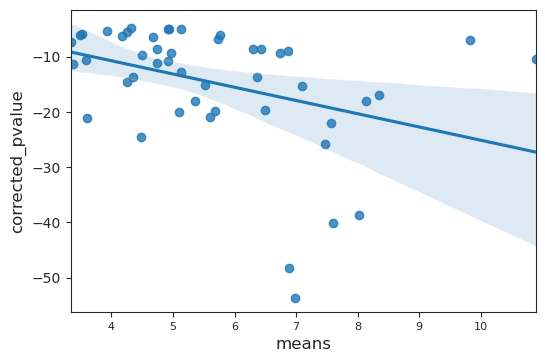

In [155]:
data = tests[tests.corrected_pvalue < 0.01]
y = np.log(data['corrected_pvalue'])
sns.regplot(data = data, x = 'means', y = y)

In [168]:
tests[tests.gene == 'IGLC3']

,n_cells,n_counts,highly_variable,means,dispersions,dispersions_norm,score,gene,pvalue,corrected_pvalue
3874,1318,4660867.0,True,6.979388,10.845972,3.072251,0.0,IGLC3,1.451427e-27,4.907275e-24


In [131]:
genes = tests.gene[:30].values

In [132]:
divisiondf = compareGenesbyDivision(_df[genes], adata)

['IGLC3' 'IGKC' 'CCL17' 'PRDM1' 'CCL22' 'ENSG00000277048' 'ACTBP2' 'AFF3'
 'JCHAIN' 'IGHE' 'LGALS1' 'IGHG1' 'IGHM' 'ANXA6' 'ACTN4' 'FSCN1' 'ESD'
 'NIN' 'IGHG4' 'IGHD' 'IGHG2' 'SCARB1' 'STOM' 'ARL16' 'TNFAIP3' 'EHD3'
 'CCL5' 'SSR4' 'RUFY3' 'PROSER1']


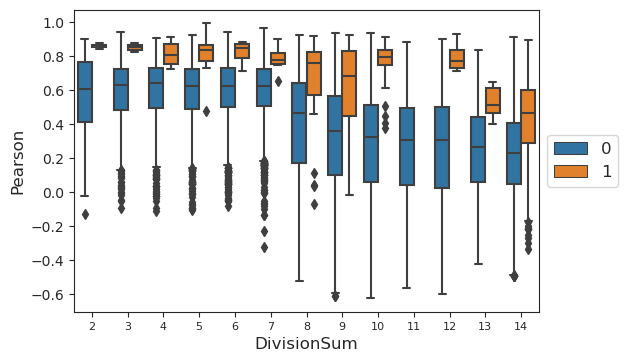

In [133]:
print(genes)
fig , ax = plt.subplots(1,1)
data = divisiondf[divisiondf['DivisionSum'] < 100]
sns.boxplot(data=data, x = 'DivisionSum', y = 'Pearson', hue = 'Clonal?')
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))

['IGHM', 'IGHD', 'IGHG1', 'IGHG2', 'IGHG3', 'IGHG4', 'IGHA1', 'IGHE', 'IGHA2']


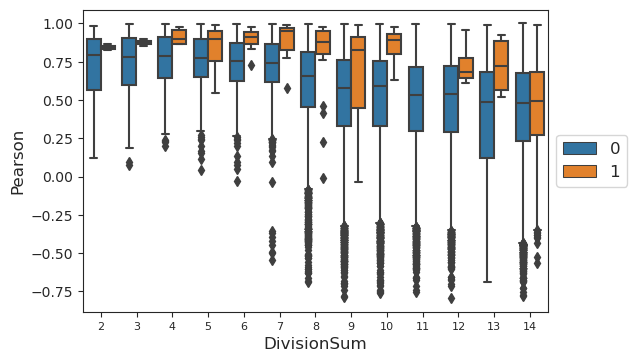

In [134]:
genes = ['IGHM', 'IGHD', 'IGHG1', 'IGHG2', 'IGHG3', 'IGHG4', 'IGHA1', 'IGHE', 'IGHA2']
divisiondf = compareGenesbyDivision(_df[genes], adata)


['IGHM', 'IGHD', 'IGHG1', 'IGHG2', 'IGHG3', 'IGHG4', 'IGHA1', 'IGHE', 'IGHA2']


Text(0.5, 1.0, 'IGH Locus')

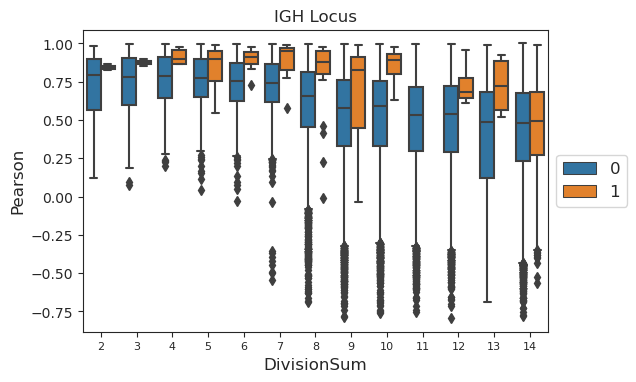

In [135]:
print(genes)
fig , ax = plt.subplots(1,1)
data = divisiondf[divisiondf['DivisionSum'] < 100]
sns.boxplot(data=data, x = 'DivisionSum', y = 'Pearson', hue = 'Clonal?')
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.title('IGH Locus')

['LGALS1' 'ENSG00000277048' 'IGKC' 'IGHE' 'FTL' 'IGHG2' 'ITGA4' 'IGLC2'
 'ANXA6' 'ACTBP2' 'IGLC3' 'JCHAIN' 'GATM' 'CCL17' 'IGHG3' 'ORAI3' 'ZNF766'
 'SLA' 'TNFAIP2' 'AC018926.2' 'COMT' 'AFF3' 'ALPL' 'ITGAX' 'IGHM' 'SRGN'
 'POTEF' 'HSPA5' 'SLC1A4' 'CCL5']


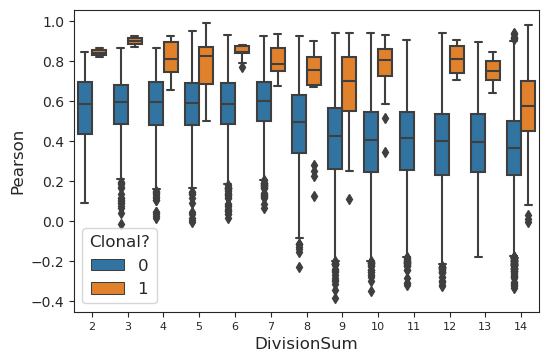

In [112]:
print(genes)
fig , ax = plt.subplots(1,1)
data = divisiondf[divisiondf['DivisionSum'] < 100]
sns.boxplot(data=data, x = 'DivisionSum', y = 'Pearson', hue = 'Clonal?')

In [ ]:
sns.pointplot()

In [454]:
adata.obs.CLONE.value_counts()

2175.0    36
1913.0    14
1462.0     6
1502.0     6
458.0      6
          ..
1638.0     1
1636.0     1
1633.0     1
1632.0     1
111.0      1
Name: CLONE, Length: 1150, dtype: int64

In [103]:
data[data.DivisionSum > 10]

,Comparison,Clonal?,DivisionSum,Pearson
0,CTY_L1_CTY_J10,0,13,0.214671
3,CTY_L1_CTY_B15,0,13,0.501845
4,CTY_L1_MS_IL4_N11,0,11,0.593756
5,CTY_L1_MS_IL4_J6,0,12,0.579128
7,CTY_L1_CTY_C12,0,11,0.56235
...,...,...,...,...
65689,P1_5_23_19_D2_A19_P1_CTV_5_15_19_M19,0,14,0.287934
65690,P1_5_23_19_D2_A19_D2_5_10_SplitSort_Dilution_C...,0,14,0.524934
65715,P1_5_23_19_D2_M5_P1_CTV_5_15_19_M19,0,14,0.214328
65716,P1_5_23_19_D2_M5_D2_5_10_SplitSort_Dilution_Co...,0,14,0.132369


In [408]:
df = sns.load_dataset('titanic')

In [419]:
selector = [0,1,2,7,8,9,10]

selected_df = df[df.index.isin(selector)]

In [420]:
selected_df.embark_town.value_counts()

Southampton    5
Cherbourg      2
Name: embark_town, dtype: int64

In [421]:
df.embark_town.value_counts()

Southampton    644
Cherbourg      168
Queenstown      77
Name: embark_town, dtype: int64

In [451]:

divisiondf['Clonal?'].value_counts()

0    64999
1     1067
Name: Clonal?, dtype: int64

In [ ]:
divisiondf 